# Bakery demo

This notebook shows a Bakery demo of [AutoPred](https://autopred.sloxen.com/), which is designed to predict the growths and risks of small businesses based on historical data.

## Table of contents

[Import Libaries](#import-libraries)

Load the bakery data from [Kaggle](https://www.kaggle.com/datasets/akashdeepkuila/bakery/data)

Convert raw transactions into item-level `quantity`

Create a few simple features

Split the data into **training**, **validation**, and **testing** sets by date

Train a few simple candidate models

Compare them on the validation set

Choose the best validation model

[Score Models](#score)



## Import libraries

We only use a small set of standard tools:

- `pandas` and `numpy` for data handling
- `matplotlib` for quick plots
- `scikit-learn` for simple predictive models


In [1]:
# Import pandas for table-like data handling
import pandas as pd

# Import numpy for numeric operations
import numpy as np

# Import matplotlib for simple plotting
import matplotlib.pyplot as plt

# Import utilities for splitting and preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Import a few simple candidate models
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Import scoring metrics
from sklearn.metrics import mean_squared_error, r2_score

# Make notebook tables easier to read
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Print a confirmation message
print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the raw bakery data

We keep the raw file unchanged in `df_raw`.
That makes debugging easier later.


In [2]:
# Read the CSV file into a dataframe
df_raw = pd.read_csv("demo/bakery_kaggle/bakery_sales_revised.csv")

# Show the first few rows
df_raw.head()


,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,10/30/2016 9:58,morning,weekend
1,2,Scandinavian,10/30/2016 10:05,morning,weekend
2,2,Scandinavian,10/30/2016 10:05,morning,weekend
3,3,Hot chocolate,10/30/2016 10:07,morning,weekend
4,3,Jam,10/30/2016 10:07,morning,weekend


In [3]:
# Print the shape of the raw data
print("Shape of raw data:", df_raw.shape)

# Print the column names
print("\nColumn names:")
print(df_raw.columns.tolist())

# Print missing values per column
print("\nMissing values per column:")
print(df_raw.isna().sum())


Shape of raw data: (20507, 5)

Column names:
['Transaction', 'Item', 'date_time', 'period_day', 'weekday_weekend']

Missing values per column:
Transaction        0
Item               0
date_time          0
period_day         0
weekday_weekend    0
dtype: int64


## 3. Parse the datetime column

We convert `date_time` into a proper datetime field.
Then we create some simple time features.


In [4]:
# Make a working copy so the raw dataframe stays untouched
df = df_raw.copy()

# Convert the text datetime column into pandas datetime
df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")

# Create a pure date column for daily grouping and time splitting
df["date"] = df["date_time"].dt.date

# Create hour of day
df["hour"] = df["date_time"].dt.hour

# Create month number
df["month"] = df["date_time"].dt.month

# Create day name such as Monday or Tuesday
df["day_name"] = df["date_time"].dt.day_name()

# Show a preview
df.head()


,Transaction,Item,date_time,period_day,weekday_weekend,date,hour,month,day_name
0,1,Bread,2016-10-30 09:58:00,morning,weekend,2016-10-30,9,10,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,2016-10-30,10,10,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,2016-10-30,10,10,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,2016-10-30,10,10,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,2016-10-30,10,10,Sunday


In [5]:
# Count invalid or missing datetime values
print("Invalid or missing date_time values:", df["date_time"].isna().sum())

# Show rows where datetime parsing failed, if any
df[df["date_time"].isna()].head()


Invalid or missing date_time values: 0


,Transaction,Item,date_time,period_day,weekday_weekend,date,hour,month,day_name


## 4. Aggregate the raw transactions into `quantity`

The raw dataset is one row per sold item.

For prediction, we build a table where each row represents:
- one date
- one item
- one period of day
- one weekday/weekend category

The target variable is `quantity`.


In [6]:
# Group the raw rows into item-level quantity
qty_df = (
    df.groupby(["date", "Item", "period_day", "weekday_weekend"])
      .size()
      .reset_index(name="quantity")
)

# Convert the grouped date column back to pandas datetime
qty_df["date"] = pd.to_datetime(qty_df["date"])

# Show the first few grouped rows
qty_df.head()


,date,Item,period_day,weekday_weekend,quantity
0,2016-10-30,Basket,morning,weekend,2
1,2016-10-30,Bread,afternoon,weekend,9
2,2016-10-30,Bread,morning,weekend,20
3,2016-10-30,Cake,afternoon,weekend,1
4,2016-10-30,Chicken sand,afternoon,weekend,1


In [7]:
# Print the shape of the modelling table
print("Shape of quantity table:", qty_df.shape)

# Print the number of unique items
print("Number of unique items:", qty_df["Item"].nunique())

# Print a summary of the target variable
print("\nQuantity summary:")
print(qty_df["quantity"].describe())


Shape of quantity table: (5627, 5)
Number of unique items: 94

Quantity summary:
count    5627.000000
mean        3.644393
std         4.603694
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        39.000000
Name: quantity, dtype: float64


## 5. Create a few simple features

We keep the feature set small and easy to debug.

Features used:
- `Item`
- `period_day`
- `weekday_weekend`
- `month`


In [8]:
# Create month as a plain integer feature from the grouped date
qty_df["month"] = qty_df["date"].dt.month

# Keep only the columns needed for modelling
model_df = qty_df[["date", "Item", "period_day", "weekday_weekend", "month", "quantity"]].copy()

# Show the modelling dataframe
model_df.head()


,date,Item,period_day,weekday_weekend,month,quantity
0,2016-10-30,Basket,morning,weekend,10,2
1,2016-10-30,Bread,afternoon,weekend,10,9
2,2016-10-30,Bread,morning,weekend,10,20
3,2016-10-30,Cake,afternoon,weekend,10,1
4,2016-10-30,Chicken sand,afternoon,weekend,10,1


## 6. Split the data into training, validation, and testing sets

We split by **date order**, not randomly.

This is important because:
- training should use older data
- validation should use later data
- testing should use the newest unseen data


In [9]:
# Sort the data by date so the split follows time order
model_df = model_df.sort_values("date").reset_index(drop=True)

# Choose split cutoffs using date quantiles
train_cutoff = model_df["date"].quantile(0.70)
val_cutoff = model_df["date"].quantile(0.85)

# Create the training set
train_df = model_df[model_df["date"] <= train_cutoff].copy()

# Create the validation set
val_df = model_df[(model_df["date"] > train_cutoff) & (model_df["date"] <= val_cutoff)].copy()

# Create the testing set
test_df = model_df[model_df["date"] > val_cutoff].copy()

# Print the sizes
print("Train size:", train_df.shape)
print("Validation size:", val_df.shape)
print("Test size:", test_df.shape)

# Print the actual date ranges
print("\nTrain range:", train_df["date"].min(), "to", train_df["date"].max())
print("Validation range:", val_df["date"].min(), "to", val_df["date"].max())
print("Test range:", test_df["date"].min(), "to", test_df["date"].max())


Train size: (3947, 6)
Validation size: (850, 6)
Test size: (830, 6)

Train range: 2016-10-30 00:00:00 to 2017-02-23 00:00:00
Validation range: 2017-02-24 00:00:00 to 2017-03-18 00:00:00
Test range: 2017-03-19 00:00:00 to 2017-04-09 00:00:00


## 7. Define feature columns and target column

We keep this explicit to make debugging easy.


In [10]:
# Define the input feature column names
feature_cols = ["Item", "period_day", "weekday_weekend", "month"]

# Define the target column name
target_col = "quantity"

# Split each dataset into X and y
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

# Print a quick shape check
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)


X_train shape: (3947, 4)
X_val shape: (850, 4)
X_test shape: (830, 4)


## 8. Build a simple preprocessing step

The feature columns are mostly categorical.

We use:
- one-hot encoding for `Item`, `period_day`, and `weekday_weekend`
- pass-through for `month`


In [11]:
# Define which columns are categorical
categorical_features = ["Item", "period_day", "weekday_weekend"]

# Define which columns are numeric
numeric_features = ["month"]

# Create a preprocessing transformer
# OneHotEncoder converts categories into 0/1 columns
# handle_unknown="ignore" prevents errors if validation/test contains unseen labels
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# Show the preprocessor object
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 9. Define simple candidate models

We keep the model list simple:

- `Dummy_Mean`: predicts the training mean every time
- `Linear_Regression`: simple linear model
- `Ridge`: linear model with a little regularisation
- `Random_Forest`: simple tree-based model


In [12]:
# Create a dictionary of candidate models
candidate_models = {
    "Dummy_Mean": DummyRegressor(strategy="mean"),
    "Linear_Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random_Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
}

# Show the model names
list(candidate_models.keys())


['Dummy_Mean', 'Linear_Regression', 'Ridge', 'Random_Forest']

## 10. Train each model on the training set only

For each candidate model:
- build a pipeline
- fit on the training set
- store the fitted pipeline


In [13]:
# Create a dictionary to store the fitted pipelines
fitted_pipelines = {}

# Loop through each candidate model
for model_name, model in candidate_models.items():
    # Print progress so the notebook is easier to follow
    print(f"Training {model_name} ...")

    # Create a pipeline with preprocessing first, then the model
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Fit the pipeline on training data only
    pipeline.fit(X_train, y_train)

    # Store the fitted pipeline
    fitted_pipelines[model_name] = pipeline

    # Print completion message
    print(f"{model_name} training complete.")
    print("-" * 50)

print("All candidate models trained.")


Training Dummy_Mean ...
Dummy_Mean training complete.
--------------------------------------------------
Training Linear_Regression ...
Linear_Regression training complete.
--------------------------------------------------
Training Ridge ...
Ridge training complete.
--------------------------------------------------
Training Random_Forest ...
Random_Forest training complete.
--------------------------------------------------
All candidate models trained.


## 11. Score each candidate model on the validation set

This is the model-selection step.

We use the validation set to compare models fairly.
We choose the model with the lowest validation RMSE.


In [14]:
# Define a helper function for scoring predictions
def score_predictions(y_true, y_pred):
    # Calculate mean squared error
    mse = mean_squared_error(y_true, y_pred)

    # Convert MSE into RMSE
    rmse = np.sqrt(mse)

    # Calculate R-squared
    r2 = r2_score(y_true, y_pred)

    # Return all metrics in one dictionary
    return {"MSE": mse, "RMSE": rmse, "R2": r2}


In [15]:
# Create an empty list to collect validation results
validation_rows = []

# Loop through fitted models
for model_name, pipeline in fitted_pipelines.items():
    # Predict on the validation set
    val_pred = pipeline.predict(X_val)

    # Prevent negative quantity predictions
    val_pred = np.clip(val_pred, a_min=0, a_max=None)

    # Score the validation predictions
    metrics = score_predictions(y_val, val_pred)

    # Save one result row
    validation_rows.append({
        "model_name": model_name,
        "val_MSE": metrics["MSE"],
        "val_RMSE": metrics["RMSE"],
        "val_R2": metrics["R2"]
    })

# Convert the results into a dataframe and sort by validation RMSE
validation_results = pd.DataFrame(validation_rows).sort_values("val_RMSE").reset_index(drop=True)

# Show the validation comparison table
validation_results


,model_name,val_MSE,val_RMSE,val_R2
0,Random_Forest,4.761592,2.182107,0.769912
1,Linear_Regression,6.930733,2.632629,0.665095
2,Ridge,6.950613,2.636402,0.664134
3,Dummy_Mean,20.741470,4.554280,-0.002264


## 12. Choose the best validation model

The best model is the one with the lowest validation RMSE.


In [16]:
# Pick the best model name from the first row of the sorted validation table
best_model_name = validation_results.loc[0, "model_name"]

# Fetch the corresponding fitted pipeline
best_pipeline = fitted_pipelines[best_model_name]

# Print the chosen model
print("Best model chosen from validation:", best_model_name)


Best model chosen from validation: Random_Forest


## <a name="score"></a>Score Models

This is the full simple predictive workflow:

- train on training data
- choose on validation data
- report final performance on testing data


In [17]:
# Define a helper function to evaluate one dataset
def evaluate_dataset(name, pipeline, X, y):
    # Generate predictions
    pred = pipeline.predict(X)

    # Prevent negative quantity predictions
    pred = np.clip(pred, a_min=0, a_max=None)

    # Score the predictions
    metrics = score_predictions(y, pred)

    # Print results
    print(f"{name} MSE:  {metrics['MSE']:.4f}")
    print(f"{name} RMSE: {metrics['RMSE']:.4f}")
    print(f"{name} R2:   {metrics['R2']:.4f}")
    print("-" * 50)

    # Return predictions and metrics
    return pred, metrics

# Evaluate the chosen model on train, validation, and test
train_pred, train_metrics = evaluate_dataset("TRAIN", best_pipeline, X_train, y_train)
val_pred, val_metrics = evaluate_dataset("VALIDATION", best_pipeline, X_val, y_val)
test_pred, test_metrics = evaluate_dataset("TEST", best_pipeline, X_test, y_test)


TRAIN MSE:  4.9606
TRAIN RMSE: 2.2272
TRAIN R2:   0.7748
--------------------------------------------------
VALIDATION MSE:  4.7616
VALIDATION RMSE: 2.1821
VALIDATION R2:   0.7699
--------------------------------------------------
TEST MSE:  4.7554
TEST RMSE: 2.1807
TEST R2:   0.7299
--------------------------------------------------


In [18]:
# Create a compact final metrics table
final_metrics_table = pd.DataFrame([
    {"dataset": "TRAIN", "MSE": train_metrics["MSE"], "RMSE": train_metrics["RMSE"], "R2": train_metrics["R2"]},
    {"dataset": "VALIDATION", "MSE": val_metrics["MSE"], "RMSE": val_metrics["RMSE"], "R2": val_metrics["R2"]},
    {"dataset": "TEST", "MSE": test_metrics["MSE"], "RMSE": test_metrics["RMSE"], "R2": test_metrics["R2"]}
])

# Show the final metrics table
final_metrics_table


,dataset,MSE,RMSE,R2
0,TRAIN,4.960580,2.227236,0.774792
1,VALIDATION,4.761592,2.182107,0.769912
2,TEST,4.755354,2.180677,0.729927


## 14. Store the chosen-model predictions back into the split dataframes

This makes later plotting and export easier.


In [19]:
# Add predictions back to the split dataframes
train_scored_df = train_df.copy()
val_scored_df = val_df.copy()
test_scored_df = test_df.copy()

# Store predicted quantity
train_scored_df["pred_quantity"] = train_pred
val_scored_df["pred_quantity"] = val_pred
test_scored_df["pred_quantity"] = test_pred

# Show the test dataframe with predictions
test_scored_df.head()


,date,Item,period_day,weekday_weekend,month,quantity,pred_quantity
4797,2017-03-19,Pastry,afternoon,weekend,3,3,2.862795
4798,2017-03-19,Smoothies,afternoon,weekend,3,1,2.174758
4799,2017-03-19,Salad,afternoon,weekend,3,3,2.174758
4800,2017-03-19,Sandwich,afternoon,weekend,3,9,5.008665
4801,2017-03-19,Scone,afternoon,weekend,3,4,2.862828


## 15. Plot observed vs predicted quantity on the test set

This gives a simple visual check of how the chosen model behaves on unseen data.


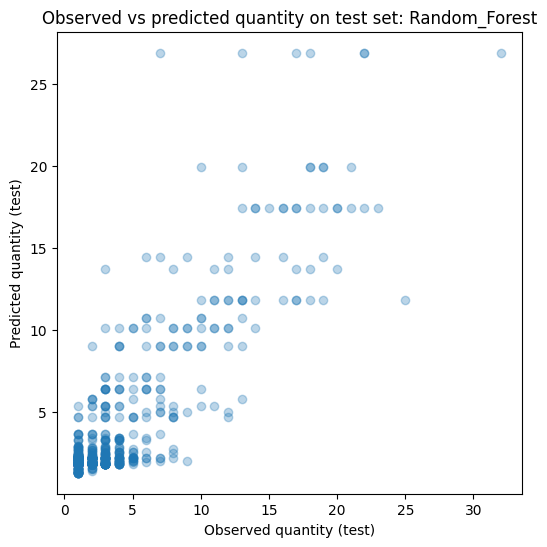

In [20]:
# Create a scatter plot for the test set
plt.figure(figsize=(6, 6))
plt.scatter(test_scored_df["quantity"], test_scored_df["pred_quantity"], alpha=0.3)

# Label the axes
plt.xlabel("Observed quantity (test)")
plt.ylabel("Predicted quantity (test)")

# Add a title
plt.title(f"Observed vs predicted quantity on test set: {best_model_name}")

# Show the plot
plt.show()


## 16. Optional pseudo-price revenue layer

This is optional.
The main prediction task is quantity.

We now convert predicted quantity into pseudo revenue for a simple business view.


In [21]:
# Define example pseudo prices
base_price_map = {
    "Coffee": 2.8,
    "Bread": 3.5,
    "Tea": 2.5,
    "Cake": 4.8,
    "Pastry": 3.8,
    "Sandwich": 5.5,
    "Medialuna": 2.7,
    "Hot chocolate": 3.2,
    "Cookies": 2.4,
    "Brownie": 3.0,
    "Farm House": 4.5,
    "Muffin": 2.9,
    "Alfajores": 2.6,
    "Juice": 3.0,
    "Soup": 4.9,
    "Scone": 2.8,
    "Toast": 3.2,
    "Scandinavian": 3.8,
    "Truffles": 3.4,
    "Coke": 2.2
}

# Use a default price for items not explicitly listed
default_price = 3.5

# Apply base price to each scored dataframe
for frame in [train_scored_df, val_scored_df, test_scored_df]:
    frame["base_price"] = frame["Item"].map(base_price_map).fillna(default_price)


In [22]:
# Define a simple owner price adjustment scenario
owner_price_adjustment = {
    "Coffee": 1.10,
    "Bread": 1.00,
    "Tea": 0.95,
    "Cake": 1.15,
    "Pastry": 1.05
}

# Apply adjusted prices
for frame in [train_scored_df, val_scored_df, test_scored_df]:
    frame["adjusted_price"] = frame.apply(
        lambda row: row["base_price"] * owner_price_adjustment.get(row["Item"], 1.0),
        axis=1
    )

# Create predicted revenue under baseline and adjusted pricing
for frame in [train_scored_df, val_scored_df, test_scored_df]:
    frame["pred_revenue_base"] = frame["pred_quantity"] * frame["base_price"]
    frame["pred_revenue_adjusted"] = frame["pred_quantity"] * frame["adjusted_price"]

# Show the test set
test_scored_df.head()


,date,Item,period_day,weekday_weekend,month,quantity,pred_quantity,base_price,adjusted_price,pred_revenue_base,pred_revenue_adjusted
4797,2017-03-19,Pastry,afternoon,weekend,3,3,2.862795,3.8,3.99,10.878621,11.422553
4798,2017-03-19,Smoothies,afternoon,weekend,3,1,2.174758,3.5,3.50,7.611653,7.611653
4799,2017-03-19,Salad,afternoon,weekend,3,3,2.174758,3.5,3.50,7.611653,7.611653
4800,2017-03-19,Sandwich,afternoon,weekend,3,9,5.008665,5.5,5.50,27.547660,27.547660
4801,2017-03-19,Scone,afternoon,weekend,3,4,2.862828,2.8,2.80,8.015918,8.015918


## 17. Summarise test-set revenue by item

This is just a simple business-facing summary.


In [23]:
# Aggregate predicted revenue by item on the test set
test_revenue_compare = (
    test_scored_df.groupby("Item")[["pred_revenue_base", "pred_revenue_adjusted"]]
    .sum()
    .sort_values("pred_revenue_base", ascending=False)
)

# Show the top rows
test_revenue_compare.head(15)


,pred_revenue_base,pred_revenue_adjusted
Item,,
Coffee,2173.085793,2390.394372
Bread,1725.875534,1725.875534
Cake,897.702938,1032.358379
Sandwich,688.757487,688.757487
Tea,522.896996,496.752146
Pastry,349.115527,366.571303
Soup,294.413278,294.413278
Farm House,214.893137,214.893137
Juice,209.680674,209.680674


## 18. Export outputs

We export:
- scored train / validation / test datasets
- validation comparison table
- final metrics table


In [24]:
# Export scored split dataframes
train_scored_df.to_csv("demo/bakery_kaggle/bakery_train_predictions_simple.csv", index=False)
val_scored_df.to_csv("demo/bakery_kaggle/bakery_validation_predictions_simple.csv", index=False)
test_scored_df.to_csv("demo/bakery_kaggle/bakery_test_predictions_simple.csv", index=False)

# Export comparison and final score tables
validation_results.to_csv("demo/bakery_kaggle/bakery_validation_model_comparison_simple.csv", index=False)
final_metrics_table.to_csv("demo/bakery_kaggle/bakery_final_metrics_table_simple.csv", index=False)

# Print completion message
print("Export complete.")


Export complete.


In [25]:
# Show the current working directory so exported files are easier to find
import os
print("Current working directory:")
print(os.getcwd())


Current working directory:
/mnt/c/Users/xilu/OneDrive/bus/sloxen/products/AutoPred
